----
#### lag rolling 있는 버전

In [76]:
import pandas as pd
import numpy as np
import requests
import holidays
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# -----------------------------
# 1. 기본 전처리
# -----------------------------
def filter_station(df, station_id):
    mask = (
        df['시작_대여소_ID'].astype(str).str.contains(station_id, na=False) |
        df['종료_대여소_ID'].astype(str).str.contains(station_id, na=False)
    )
    return df.loc[mask].copy()

def update_end_time(df, station_id):
    df = df.copy()
    df["전체_이용_분"] = pd.to_timedelta(df["전체_이용_분"], errors="coerce")
    df["기준_날짜"] = pd.to_datetime(df["기준_날짜"])
    df["시간대"] = pd.to_numeric(df["시간대"], errors="coerce").astype("int64")
    mask = df["종료_대여소_ID"] == station_id
    hours = df.loc[mask, "전체_이용_분"].dt.total_seconds() / 3600.0
    raw = np.floor(df.loc[mask, "시간대"] - hours).astype("int64")
    day_shift = np.floor_divide(raw, 24).astype("int64")
    adj_hour = (raw - day_shift * 24).astype("int64")
    df.loc[mask, "기준_날짜"] = df.loc[mask, "기준_날짜"] + pd.to_timedelta(day_shift, unit="D")
    df.loc[mask, "시간대"] = adj_hour.to_numpy(dtype="int64")
    df.loc[mask, "집계_기준"] = "도착시간"
    return df.sort_values(["기준_날짜", "시간대"]).reset_index(drop=True)

def build_hourly(df):
    df = df.copy()
    df["기준_날짜"] = pd.to_datetime(df["기준_날짜"])
    start = df["기준_날짜"].min()
    end = df["기준_날짜"].max()
    hours = pd.date_range(start, end + pd.Timedelta(hours=23), freq="h")
    base = pd.DataFrame({"_dt": hours})
    base = pd.concat([
        base.assign(집계_기준="출발시간"),
        base.assign(집계_기준="도착시간")
    ])
    base["기준_날짜"] = base["_dt"].dt.floor("D")
    base["시간대"] = base["_dt"].dt.hour
    base = base.drop(columns="_dt")
    counts = (
        df.groupby(["기준_날짜", "시간대", "집계_기준"])["전체_건수"]
        .sum()
        .reset_index()
    )
    base = base.merge(counts, on=["기준_날짜", "시간대", "집계_기준"], how="left")
    base["전체_건수"] = base["전체_건수"].fillna(0)
    return base.sort_values(["기준_날짜", "시간대"]).reset_index(drop=True)

# -----------------------------
# 2. 날씨
# -----------------------------
def get_weather(start_date, end_date, lat=37.6, lon=126.93):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "temperature_2m,relative_humidity_2m,precipitation,snowfall",
        "timezone": "Asia/Seoul",
    }
    data = requests.get(url, params=params).json()["hourly"]
    weather = pd.DataFrame({
        "time": pd.to_datetime(data["time"]),
        "온도": data["temperature_2m"],
        "습도": data["relative_humidity_2m"],
        "강수량": data["precipitation"],
        "적설량": data["snowfall"],
    })
    weather["기준_날짜"] = weather["time"].dt.floor("D")
    weather["시간대"] = weather["time"].dt.hour
    weather["is_rain"] = (weather["강수량"] > 0).astype(int)
    weather["is_snow"] = (weather["적설량"] > 0).astype(int)
    weather["discomfort_index"] = 0.81*weather["온도"] + 0.01*weather["습도"]*(0.99*weather["온도"] - 14.3) + 46.3
    return weather.drop(columns="time")

def merge_weather(df, weather):
    return df.merge(weather, on=["기준_날짜", "시간대"], how="left")

# -----------------------------
# 3. 주말/휴일
# -----------------------------
def add_holiday_features(df):
    df = df.copy()
    kr_holidays = holidays.KR()
    date = pd.to_datetime(df["기준_날짜"])
    is_holiday = date.isin(kr_holidays).astype(int)
    is_weekend = (date.dt.dayofweek >= 5).astype(int)
    df["is_holiday_or_weekend"] = ((is_holiday == 1) | (is_weekend == 1)).astype(int)
    return df

# -----------------------------
# 4. Feature Engineering
# -----------------------------
def add_features(df):
    df = df.sort_values(["station", "기준_날짜", "시간대"]).copy()
    date = pd.to_datetime(df["기준_날짜"])
    df["dow"] = date.dt.dayofweek
    df["month"] = date.dt.month
    df["hour_sin"] = np.sin(2*np.pi*df["시간대"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["시간대"]/24)
    df["is_arrival"] = (df["집계_기준"] == "도착시간").astype(int)
    df["station_id"] = df["station"].astype("category").cat.codes

    # lag features
    for l in [1,24,48,72,168]:
        df[f"lag{l}"] = df.groupby("station")["전체_건수"].shift(l)

    # rolling features
    for r in [6,12,24,48]:
        df[f"rolling{r}"] = df.groupby("station")["전체_건수"].transform(lambda x: x.shift(1).rolling(r).mean())

    # 누수 없는 평균
    grp = df.groupby(["station", "dow", "시간대"])["전체_건수"]
    cumsum = grp.cumsum() - df["전체_건수"]
    cumcnt = grp.cumcount()
    df["dow_hour_mean"] = cumsum / cumcnt
    df["prev_week_ratio"] = df["lag168"] / (df["lag24"] + 0.1)

    # rush hour feature
    df["is_rush_hour"] = ((df["시간대"].isin([7,8,9,18,19,20])) & (df["dow"] < 5)).astype(int)

    df = add_holiday_features(df)
    return df

# -----------------------------
# 5. 데이터셋 생성
# -----------------------------
def make_dataset(df, station_id, weather):
    df = filter_station(df, station_id)
    df = update_end_time(df, station_id)
    df = build_hourly(df)
    df = merge_weather(df, weather)
    df["station"] = station_id
    return df

# -----------------------------
# 6. 데이터 불러오기 + 전처리
# -----------------------------
station = pd.read_parquet("../../Data/sort_data/2024_data.parquet")
station2025 = pd.read_parquet("../../Data/sort_data/2025_data.parquet")
weather = get_weather("2024-01-01", "2025-12-31")

stations = ['ST-2247', 'ST-2252', 'ST-2425']
train_df = pd.concat([make_dataset(station, s, weather) for s in stations])
test_df = pd.concat([make_dataset(station2025, s, weather) for s in stations])

train_df = add_features(train_df)
test_df = add_features(test_df)

feature_cols = [
    "시간대","dow","month","온도","습도","강수량",
    "hour_sin","hour_cos","station_id",
    "lag24","lag48","lag72","lag168",
    "rolling6","rolling12","rolling24","rolling48",
    "dow_hour_mean","prev_week_ratio",
    "is_holiday_or_weekend","is_rain","discomfort_index","is_rush_hour"
]

target_col = "전체_건수"
train_df = train_df.dropna(subset=feature_cols+[target_col])
test_df = test_df.dropna(subset=feature_cols)

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

# -----------------------------
# 7. 모델 학습 + CV
# -----------------------------
tscv = TimeSeriesSplit(n_splits=10, gap=48)
cv_preds = []
cv_trues = []

for train_idx, val_idx in tscv.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = LGBMRegressor(
        random_state=42,
        n_estimators=2500,
        learning_rate=0.006,
        num_leaves=10,
        max_depth=6,
        min_child_samples=60,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.5,
        reg_lambda=0.5
    )
    model.fit(X_tr, y_tr)

    val_pred = model.predict(X_val)
    cv_preds.append(val_pred)
    cv_trues.append(y_val.values)

cv_preds_all = np.concatenate(cv_preds)
cv_trues_all = np.concatenate(cv_trues)

# 전체 학습
final_model = LGBMRegressor(
    random_state=42,
    n_estimators=2500,
    learning_rate=0.006,
    num_leaves=10,
    max_depth=6,
    min_child_samples=60,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.5,
    reg_lambda=0.5
)
final_model.fit(X_train, y_train)
train_pred = final_model.predict(X_train)
test_pred = final_model.predict(X_test)

# -----------------------------
# 8. 평가
# -----------------------------
def score(y, pred):
    return {
        "R2": r2_score(y, pred),
        "MAE": mean_absolute_error(y, pred),
        "RMSE": np.sqrt(mean_squared_error(y, pred))
    }

print("TRAIN:", score(y_train, train_pred))
print("CV   :", r2_score(cv_trues_all, cv_preds_all))
print("TEST :", score(y_test, test_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000737 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1333
[LightGBM] [Info] Number of data points in the train set: 4680, number of used features: 22
[LightGBM] [Info] Start training from score 0.963675
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

-----
#### 시각화

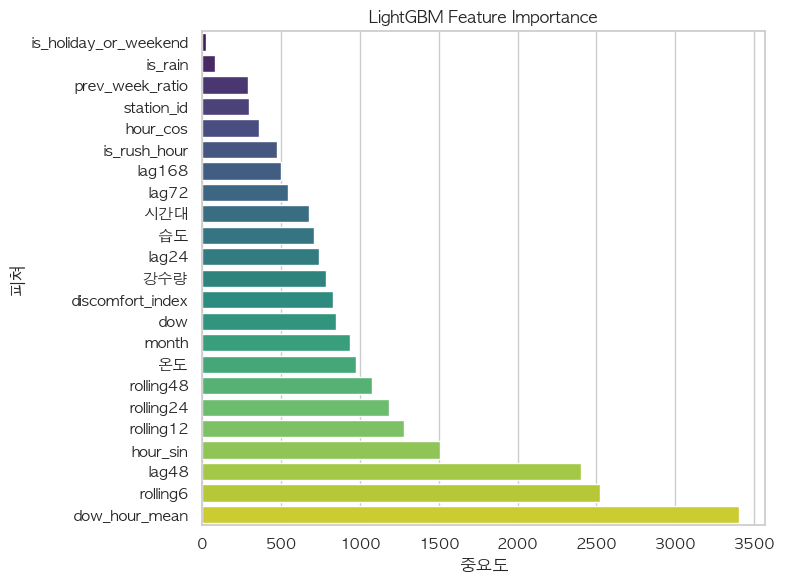

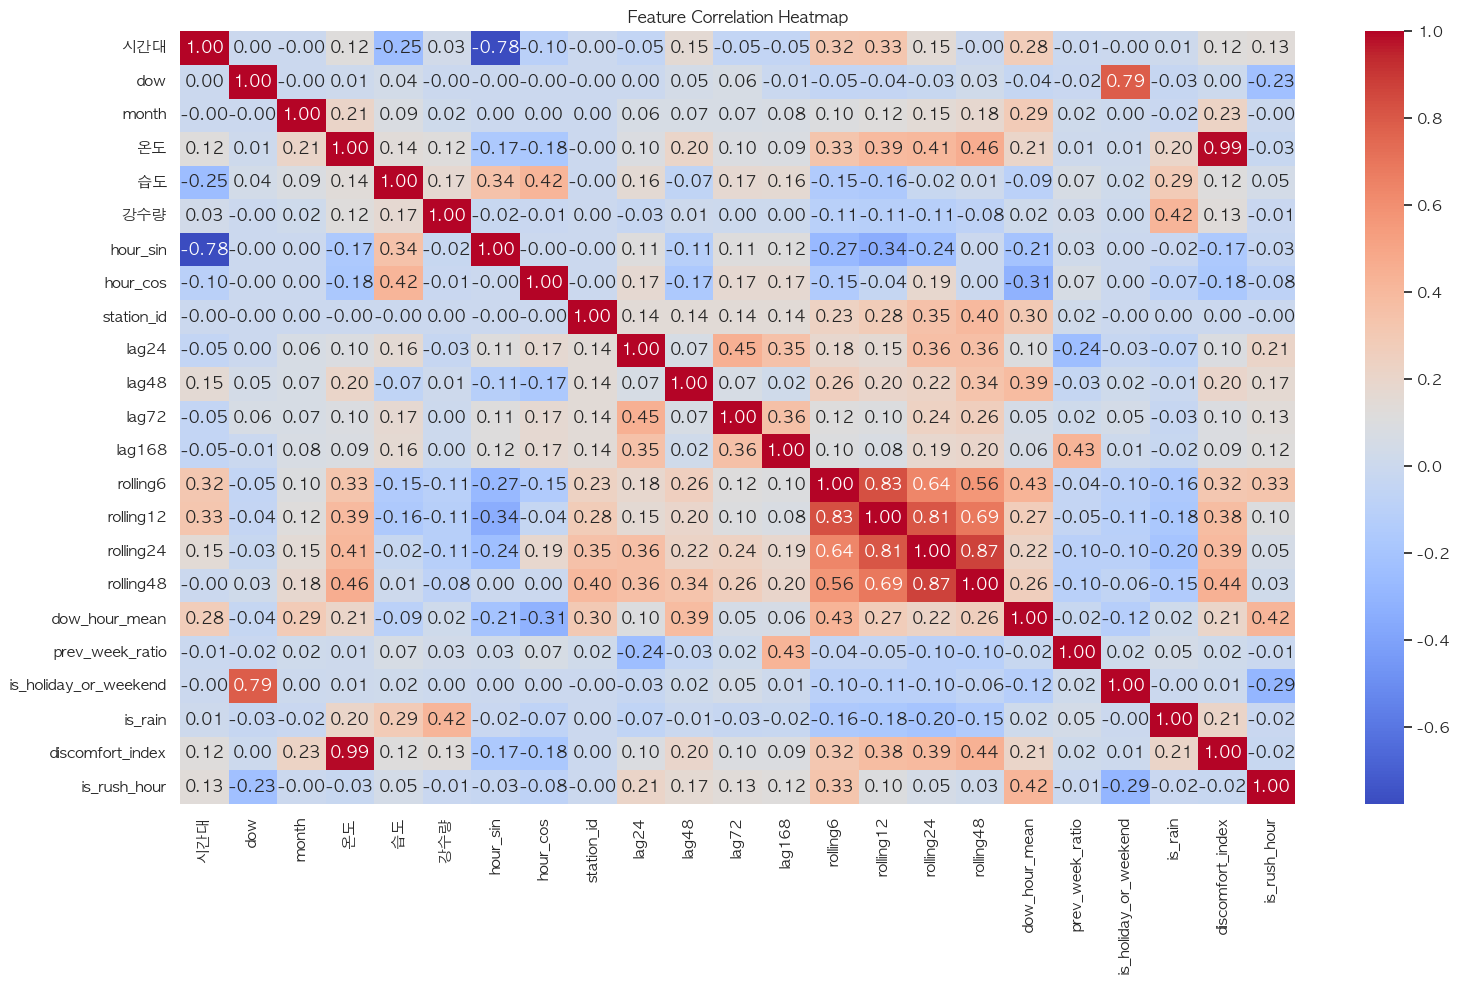

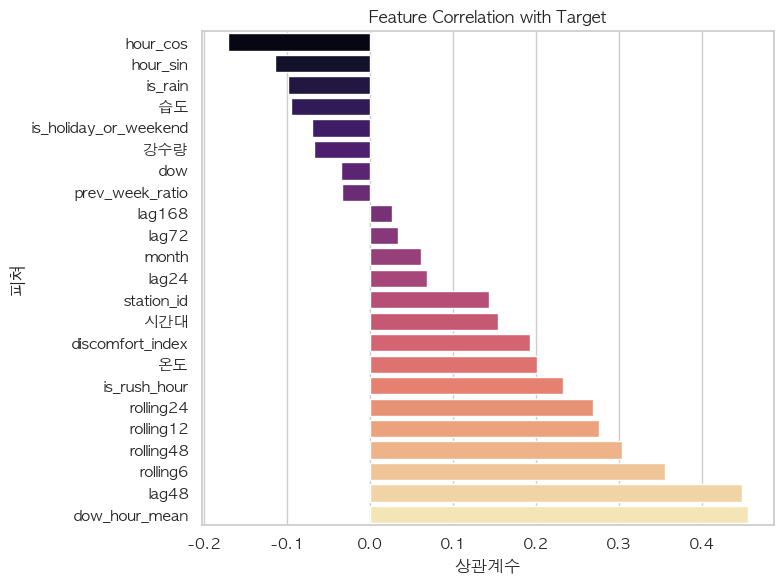

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import pandas as pd

# -----------------------------
# 0. 한글 폰트 설정 (macOS 기준)
# -----------------------------
font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'  # macOS
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['axes.unicode_minus'] = False
sns.set(style="whitegrid", font=font_prop.get_name())

# -----------------------------
# 1. Feature Importance (사용한 feature_cols 기준)
# -----------------------------
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=True)  # y축은 작은 -> 큰

plt.figure(figsize=(8,6))
sns.barplot(data=importance, x="importance", y="feature", palette="viridis")
plt.title("LightGBM Feature Importance", fontproperties=font_prop)
plt.xlabel("중요도", fontproperties=font_prop)
plt.ylabel("피쳐", fontproperties=font_prop)
plt.tight_layout()
plt.show()

# -----------------------------
# 2. Feature Correlation Heatmap
# -----------------------------
plt.figure(figsize=(16,10))  # 가로로 넓게
corr = X_train.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=False)
plt.title("Feature Correlation Heatmap", fontproperties=font_prop)
plt.tight_layout()
plt.show()

# -----------------------------
# 3. Feature vs Target Correlation
# -----------------------------
feat_target_corr = X_train.copy()
feat_target_corr[target_col] = y_train
corr2 = feat_target_corr.corr()[target_col].drop(target_col).sort_values(ascending=True)

plt.figure(figsize=(8,6))
sns.barplot(x=corr2.values, y=corr2.index, palette="magma")
plt.title("Feature Correlation with Target", fontproperties=font_prop)
plt.xlabel("상관계수", fontproperties=font_prop)
plt.ylabel("피쳐", fontproperties=font_prop)
plt.tight_layout()
plt.show()

-----
#### rolling 없는 버전

In [78]:
feature_cols_no_lag = [
    "시간대","dow","month","온도","습도","강수량",
    "hour_sin","hour_cos","station_id",
    "lag24","lag48","lag72","lag168",
    "dow_hour_mean","prev_week_ratio",
    "is_holiday_or_weekend","is_rain","discomfort_index","is_rush_hour"
]

target_col = "전체_건수"

train_df_no_lag = train_df.dropna(subset=feature_cols_no_lag + [target_col]).copy()
test_df_no_lag = test_df.dropna(subset=feature_cols_no_lag + [target_col]).copy()

X_train_no_lag = train_df_no_lag[feature_cols_no_lag]
y_train_no_lag = train_df_no_lag[target_col]
X_test_no_lag = test_df_no_lag[feature_cols_no_lag]
y_test_no_lag = test_df_no_lag[target_col]

tscv = TimeSeriesSplit(n_splits=10, gap=48)
cv_preds_no_lag = []
cv_trues_no_lag = []

for train_idx, val_idx in tscv.split(X_train_no_lag):
    X_tr = X_train_no_lag.iloc[train_idx]
    X_val = X_train_no_lag.iloc[val_idx]
    y_tr = y_train_no_lag.iloc[train_idx]
    y_val = y_train_no_lag.iloc[val_idx]

    model_no_lag = LGBMRegressor(
        random_state=42,
        n_estimators=2500,
        learning_rate=0.006,
        num_leaves=10,
        max_depth=6,
        min_child_samples=60,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.5,
        reg_lambda=0.5
    )
    model_no_lag.fit(X_tr, y_tr)

    val_pred = model_no_lag.predict(X_val)
    cv_preds_no_lag.append(val_pred)
    cv_trues_no_lag.append(y_val.values)

cv_preds_no_lag = np.concatenate(cv_preds_no_lag)
cv_trues_no_lag = np.concatenate(cv_trues_no_lag)

final_model_no_lag = LGBMRegressor(
    random_state=42,
    n_estimators=2500,
    learning_rate=0.006,
    num_leaves=10,
    max_depth=6,
    min_child_samples=60,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.5,
    reg_lambda=0.5
)
final_model_no_lag.fit(X_train_no_lag, y_train_no_lag)

train_pred_no_lag = final_model_no_lag.predict(X_train_no_lag)
test_pred_no_lag = final_model_no_lag.predict(X_test_no_lag)

print("NO LAG TRAIN:", score(y_train_no_lag, train_pred_no_lag))
print("NO LAG CV   :", r2_score(cv_trues_no_lag, cv_preds_no_lag))
print("NO LAG TEST :", score(y_test_no_lag, test_pred_no_lag))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000849 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1058
[LightGBM] [Info] Number of data points in the train set: 4680, number of used features: 18
[LightGBM] [Info] Start training from score 0.963675
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

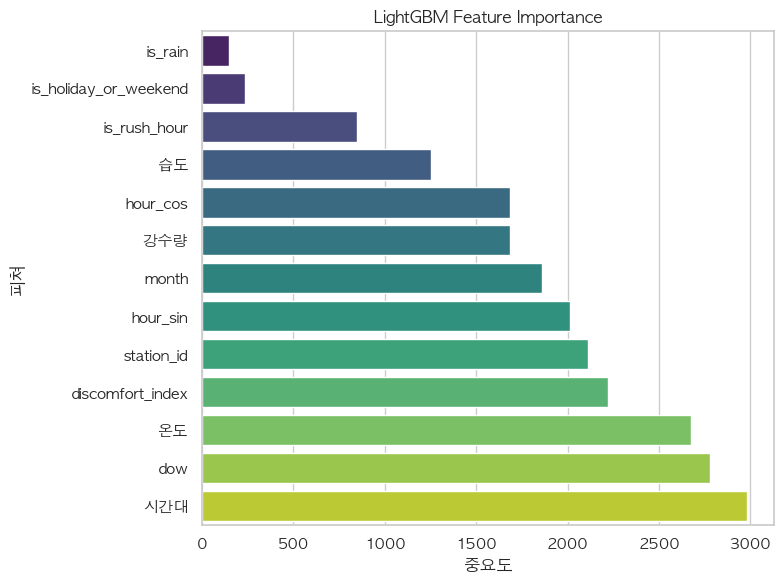

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import pandas as pd

# -----------------------------
# 0. 한글 폰트 설정 (macOS 기준)
# -----------------------------
font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'  # macOS
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['axes.unicode_minus'] = False
sns.set(style="whitegrid", font=font_prop.get_name())

# -----------------------------
# 1. Feature Importance (사용한 feature_cols 기준)
# -----------------------------
importance = pd.DataFrame({
    "feature": feature_cols_no_lag,
    "importance": final_model_no_lag.feature_importances_
}).sort_values("importance", ascending=True)  # y축은 작은 -> 큰

plt.figure(figsize=(8,6))
sns.barplot(data=importance, x="importance", y="feature", palette="viridis")
plt.title("LightGBM Feature Importance", fontproperties=font_prop)
plt.xlabel("중요도", fontproperties=font_prop)
plt.ylabel("피쳐", fontproperties=font_prop)
plt.tight_layout()
plt.show()
